# 10 - Week 3 Modeling QA

Visual checks on the baselines produced by `scripts/sweep.py` (LightGBM x 3 variants x
4 scales) and `scripts/train_cnn.py` (small CNN at S=32 and S=64). Per
[PLAN_modeling.md](../PLAN_modeling.md) §5:

- **Primary metric: Spearman rho** between predicted and true `fractional_area`,
  reported as `mean +/- std` across the 9 LOIO folds. Robust to the zero-inflated
  target and the choice of training transform.
- **Per-abundance-bin RMSE** table is the secondary diagnostic (the CLAUDE.md
  "not a single RMSE dominated by near-zero tiles" requirement).
- **Per-image calibration:** fold metrics tagged by the held-out image's BoulderLabel
  (`Boulder rich` / `Boulder poor` / `unknown` / `empty`) make per-fold variance
  interpretable.
- **ESP_065711_1545** (empty-truth image) is a *specificity-only* fold. Spearman is
  undefined when truth is constant; reported separately, not aggregated.

Methodology references:

- Tweedie compound Poisson-Gamma objective for zero-inflated continuous targets:
  [Smyth 1996](https://doi.org/10.1007/BF00140865); production-ready
  GBM treatment in [Yang et al. 2018](https://doi.org/10.1080/07350015.2016.1200981).
- Hurdle / two-part decomposition `E[Y] = P(Y>0) * E[Y|Y>0]`: original specification
  in [Mullahy 1986](https://doi.org/10.1016/0304-4076(86)90002-3).
- Positive rule for the two-stage classifier: `fractional_area > 0` (probe
  2026-05-27, see DECISIONS.md).


In [1]:
# Bootstrap order matters on Windows + Python 3.14: import src.modeling BEFORE
# numpy so the DLL/OMP setup runs before MKL preloads libiomp5md.dll. See
# src/modeling/__init__.py for the long-form explanation.
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.modeling  # noqa: F401  -- side effect: DLL bootstrap

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.modeling.loaders import iter_loio_folds, load_metadata

REPO_ROOT = Path(REPO_ROOT)
MODELS_ROOT = REPO_ROOT / 'models'
FIG_DIR = REPO_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Find the most-recent sweep dir
sweep_dirs = sorted((MODELS_ROOT / '_sweep').glob('*/'))
assert sweep_dirs, 'no models/_sweep/* runs found -- run scripts/sweep.py first'
SWEEP_DIR = sweep_dirs[-1]
print(f'sweep dir: {SWEEP_DIR.name}')

summary = pd.read_parquet(SWEEP_DIR / 'summary.parquet')
aggregate = pd.read_parquet(SWEEP_DIR / 'aggregate.parquet')
print(f'summary rows: {len(summary)}, aggregate rows: {len(aggregate)}')


sweep dir: 20260526T171527Z
summary rows: 9, aggregate rows: 1


## Sweep summary table

Aggregate metrics across the 9 LOIO folds, per `(variant, scale)`. The leftmost
column is the **primary metric** (Spearman rho `mean +/- std`); a Spearman whose
`std` swamps its `mean` is statistically zero. Per PLAN_modeling.md §11.1
("small-group CV variance") this is expected: 9 groups produce structurally large
per-fold variance, so paired-fold comparisons beat headline-mean comparisons.


In [2]:
# Pretty-print the aggregate table with the primary metric first.
display_cols = [
    'variant', 'scale_idx', 'tile_size_px',
    'spearman_rho_mean', 'spearman_rho_std',
    'presence_auc_mean', 'presence_auc_std',
    'rmse_log1p_mean', 'n_real_folds',
]
display_df = aggregate[display_cols].copy()
for c in ('spearman_rho_mean', 'spearman_rho_std', 'presence_auc_mean',
          'presence_auc_std', 'rmse_log1p_mean'):
    display_df[c] = display_df[c].round(4)
display_df.sort_values(['scale_idx', 'variant'])


,variant,scale_idx,tile_size_px,spearman_rho_mean,spearman_rho_std,presence_auc_mean,presence_auc_std,rmse_log1p_mean,n_real_folds
0,lightgbm_tweedie,0,8,0.0037,0.02,0.5126,0.0519,0.002,8


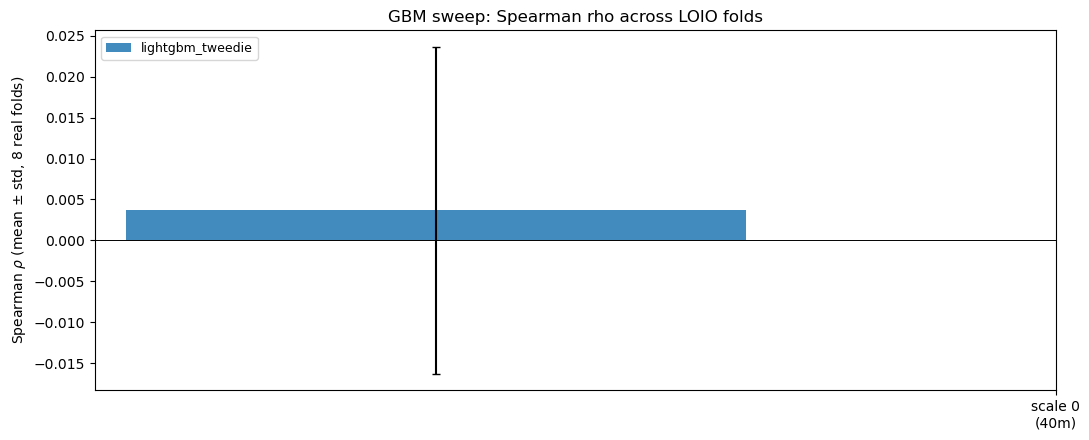

In [3]:
# Bar chart: Spearman mean +/- std per (variant, scale).
fig, ax = plt.subplots(figsize=(11, 4.5))
scales = sorted(aggregate['scale_idx'].unique())
variants = sorted(aggregate['variant'].unique())
x_base = np.arange(len(scales))
width = 0.25
for i, v in enumerate(variants):
    sub = aggregate[aggregate['variant'] == v].sort_values('scale_idx')
    means = sub['spearman_rho_mean'].to_numpy()
    stds = sub['spearman_rho_std'].to_numpy()
    ax.bar(x_base + i * width, means, width, yerr=stds, capsize=3, label=v, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.7, linestyle='-')
ax.set_xticks(x_base + width)
ax.set_xticklabels([f'scale {s}\n({40 * 2**s:.0f}m)' for s in scales])
ax.set_ylabel(r'Spearman $\rho$ (mean $\pm$ std, 8 real folds)')
ax.set_title('GBM sweep: Spearman rho across LOIO folds')
ax.legend(fontsize=9, loc='upper left')
fig.tight_layout()
fig.savefig(FIG_DIR / '10_sweep_spearman_bar.png', dpi=110)
plt.show()


## Per-fold Spearman, tagged by BoulderLabel

A single Spearman mean hides structure. Per PLAN_modeling.md §11.5 ("per-image
artifacts as features"), held-out performance is uneven across image classes -- a
model that learns brightness-as-proxy for "boulder rich" should fail systematically
on `Boulder poor` and `unknown` folds. The plot below colours each fold by its
manifest BoulderLabel so that class-conditional patterns are visible.


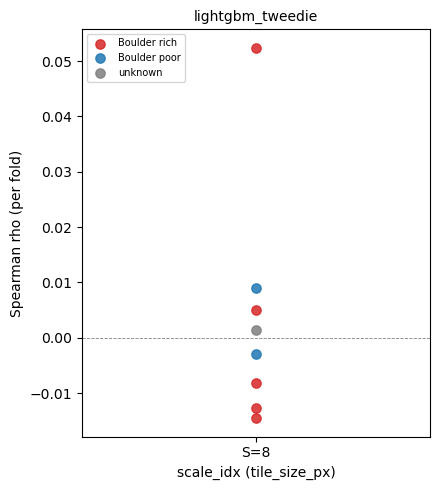

In [4]:
# Join the manifest to tag each fold's held-out ObsId with its BoulderLabel.
import src.manifest as M
from src.config import load_config

cfg = load_config('config.yaml')
manifest = M.load_manifest(cfg.manifest_path)
obs_to_label = dict(zip(manifest['ObsId'], manifest['BoulderLabel']))
summary['boulder_label'] = summary['held_out_obs_id'].map(obs_to_label).fillna('empty')

# Per-fold Spearman by variant + label
fig, axes = plt.subplots(1, len(variants), figsize=(4.5 * len(variants), 5), sharey=True, squeeze=False)
for ax, v in zip(axes[0], variants):
    sub = summary[summary['variant'] == v]
    label_colors = {'Boulder rich': 'tab:red', 'Boulder poor': 'tab:blue',
                    'unknown': 'tab:gray', 'empty': 'black'}
    for lbl, color in label_colors.items():
        sl = sub[sub['boulder_label'] == lbl]
        if sl.empty:
            continue
        ax.scatter(sl['scale_idx'], sl['spearman_rho'], color=color, alpha=0.85,
                    label=lbl, s=45)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.5)
    ax.set_xticks(sorted(sub['scale_idx'].unique()))
    ax.set_xticklabels([f'S={2**(3+s)}' for s in sorted(sub['scale_idx'].unique())])
    ax.set_xlabel('scale_idx (tile_size_px)')
    if ax is axes[0][0]:
        ax.set_ylabel('Spearman rho (per fold)')
        ax.legend(fontsize=7, loc='upper left')
    ax.set_title(v, fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / '10_per_fold_spearman_by_label.png', dpi=110)
plt.show()


## Predicted-vs-true log-log scatter (best per-scale model)

For the variant with the highest mean Spearman at each scale, plot predicted vs
true `fractional_area` per fold on a log-log axis. The dashed identity line is the
oracle. The zero-truth tiles cluster on the left edge (they get a tiny `log10` floor
applied for plotting only). PLAN_modeling.md §11.2 ("the 0.27 ceiling") frames the
structural performance cap: the densest tile in the entire dataset has only 0.269
fractional area, so the plotted dynamic range is intrinsically small.


In [5]:
# Pick best variant per scale by Spearman mean.
best_per_scale = aggregate.loc[aggregate.groupby('scale_idx')['spearman_rho_mean'].idxmax()]
print('Best variant per scale:')
print(best_per_scale[['variant', 'scale_idx', 'tile_size_px',
                       'spearman_rho_mean', 'spearman_rho_std']].to_string(index=False))


Best variant per scale:
         variant  scale_idx  tile_size_px  spearman_rho_mean  spearman_rho_std
lightgbm_tweedie          0             8           0.003686          0.019977


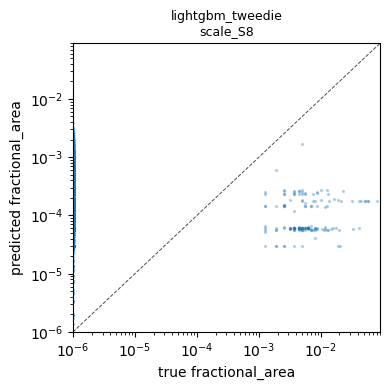

In [6]:
def scatter_for_variant_scale(variant, scale_idx, ax):
    # Each (variant, scale_idx) writes to its own config_hash dir, so glob across
    # hashes for the requested scale and take the most-recent by mtime.
    tile_size = int(2 ** (3 + scale_idx))
    scale_dirs = sorted((MODELS_ROOT / variant).glob(f'*/scale_S{tile_size}'),
                        key=lambda p: p.stat().st_mtime)
    if not scale_dirs:
        ax.set_title(f'(no scale_S{tile_size} for {variant})')
        return
    pred_path = scale_dirs[-1] / 'predictions.parquet'
    if not pred_path.exists():
        ax.set_title(f'(no predictions for {variant} S={tile_size})')
        return
    pred = pd.read_parquet(pred_path)
    # Apply tiny floor for plotting
    floor = 1e-6
    yt = np.clip(pred['y_true'].to_numpy(), floor, None)
    yp = np.clip(pred['y_pred'].to_numpy(), floor, None)
    # Subsample so the plot doesn't blow up on 50k tiles
    if len(yt) > 8000:
        idx = np.random.default_rng(0).choice(len(yt), 8000, replace=False)
        yt = yt[idx]; yp = yp[idx]
    ax.scatter(yt, yp, s=2, alpha=0.25, color='tab:blue')
    lo, hi = floor, max(yt.max(), yp.max()) * 1.1
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.7, alpha=0.7)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('true fractional_area')
    if ax is axes[0][0]:
        ax.set_ylabel('predicted fractional_area')
    ax.set_title(f'{variant}\nscale_S{tile_size}', fontsize=9)

scales_sorted = sorted(best_per_scale['scale_idx'].tolist())
fig, axes = plt.subplots(1, len(scales_sorted), figsize=(4 * len(scales_sorted), 4), squeeze=False)
for ax, scale_idx in zip(axes[0], scales_sorted):
    row = best_per_scale[best_per_scale['scale_idx'] == scale_idx].iloc[0]
    scatter_for_variant_scale(row['variant'], int(scale_idx), ax)
fig.tight_layout()
fig.savefig(FIG_DIR / '10_pred_vs_true_loglog.png', dpi=110)
plt.show()


## Per-abundance-bin RMSE heatmap

Per PLAN_modeling.md §5: "highlight tail performance." The heatmap below shows RMSE
within each true-abundance bin, per scale, for the headline variant. A uniformly
low row (across all bins) is good; a model that's tiny RMSE on the zero bin but huge
on the high bin is the failure mode the §11.2 "structural ceiling" warns about.


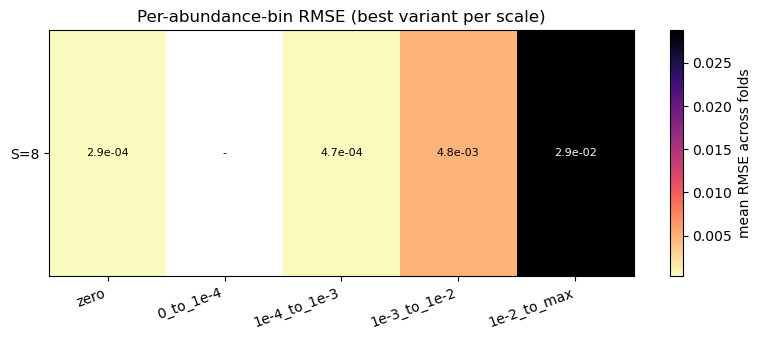

In [7]:
# Load metrics.json for each best-per-scale model and pull per-bin RMSE
import collections

bin_rmse_rows = []
for _, row in best_per_scale.iterrows():
    tile_size = int(row['tile_size_px'])
    scale_dirs = sorted((MODELS_ROOT / row['variant']).glob(f'*/scale_S{tile_size}'),
                        key=lambda p: p.stat().st_mtime)
    if not scale_dirs:
        continue
    metrics_path = scale_dirs[-1] / 'metrics.json'
    if not metrics_path.exists():
        continue
    m = json.loads(metrics_path.read_text())
    for f in m['per_fold']:
        for b in f.get('per_bin_rmse', []):
            bin_rmse_rows.append({
                'variant': row['variant'], 'scale_idx': int(row['scale_idx']),
                'tile_size_px': tile_size, 'fold_idx': f['fold_idx'],
                'bin': b['bin'], 'n_tiles': b['n_tiles'], 'rmse': b['rmse'],
            })
if bin_rmse_rows:
    bin_df = pd.DataFrame(bin_rmse_rows)
    # Per-scale mean RMSE in each bin (across folds, weighted equally)
    pivot = bin_df.groupby(['scale_idx', 'bin'])['rmse'].mean().unstack('bin')
    bin_order = ['zero', '0_to_1e-4', '1e-4_to_1e-3', '1e-3_to_1e-2', '1e-2_to_max']
    pivot = pivot[bin_order]
    fig, ax = plt.subplots(figsize=(8, 3.5))
    im = ax.imshow(pivot.values, aspect='auto', cmap='magma_r')
    ax.set_xticks(range(len(bin_order)))
    ax.set_xticklabels(bin_order, rotation=20, ha='right')
    ax.set_yticks(range(pivot.shape[0]))
    ax.set_yticklabels([f'S={2**(3+s)}' for s in pivot.index])
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            ax.text(j, i, f'{v:.1e}' if not np.isnan(v) else '-', ha='center', va='center',
                    color='white' if v > pivot.values[~np.isnan(pivot.values)].mean() else 'black',
                    fontsize=8)
    ax.set_title('Per-abundance-bin RMSE (best variant per scale)')
    fig.colorbar(im, ax=ax, label='mean RMSE across folds')
    fig.tight_layout()
    fig.savefig(FIG_DIR / '10_per_bin_rmse.png', dpi=110)
    plt.show()
else:
    print('No per-bin RMSE data yet')


## GBM feature importance (Tweedie variant)

For the Tweedie GBM at the finest scale (S=8), the booster's split-gain feature
importance ranks which of the 52 Stage 4b features most informed the predictions.
PLAN_modeling.md §2 frames this as the diagnostic question -- "which CTX texture
descriptors predict abundance?". A flat/uniform ranking means no feature is doing
heavy lifting (model is using surface noise); a heavily right-skewed ranking with
GLCM / shadow features on top means our hand-crafted features captured the right
signal.


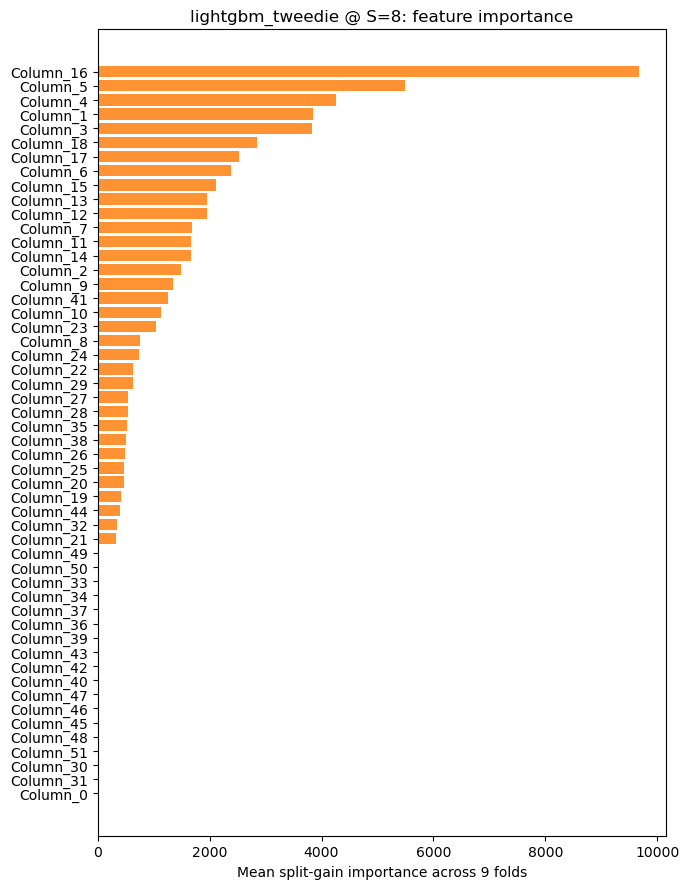

In [8]:
try:
    import lightgbm as lgb
    # Each (variant, scale) lives under its own config_hash dir; glob across hashes
    # for scale_S8 and pick the most-recent.
    scale_dirs = sorted((MODELS_ROOT / 'lightgbm_tweedie').glob('*/scale_S8'),
                        key=lambda p: p.stat().st_mtime)
    if scale_dirs:
        booster_paths = sorted(scale_dirs[-1].glob('fold_*/booster.txt'))
        importances = []
        for bp in booster_paths:
            b = lgb.Booster(model_str=bp.read_text(encoding='utf-8'))
            imp = pd.Series(b.feature_importance(importance_type='gain'), index=b.feature_name())
            importances.append(imp)
        if importances:
            agg_imp = pd.concat(importances, axis=1).mean(axis=1).sort_values(ascending=True)
            fig, ax = plt.subplots(figsize=(7, 9))
            ax.barh(agg_imp.index, agg_imp.values, color='tab:orange', alpha=0.85)
            ax.set_xlabel('Mean split-gain importance across 9 folds')
            ax.set_title('lightgbm_tweedie @ S=8: feature importance')
            fig.tight_layout()
            fig.savefig(FIG_DIR / '10_feature_importance_tweedie_S8.png', dpi=110)
            plt.show()
        else:
            print('No booster artifacts found')
    else:
        print('No tweedie scale_S8 dir found')
except Exception as e:
    print(f'feature importance skipped: {type(e).__name__}: {e}')


## CNN vs GBM at matched scale

Per PLAN_modeling.md §4: the CNN is non-optional and answers a complementary question
-- "is there additional CTX signal beyond what hand-crafted features summarize?"
If the CNN beats the GBM at S=32 / S=64, Stage 4c features are motivated. If the
GBM beats the CNN, the bottleneck is data, not feature engineering.


In [9]:
cnn_rows = []
for patch_size in (32, 64):
    name = f'cnn_log1p_huber_S{patch_size}'
    runs = sorted((MODELS_ROOT / name).glob('*'))
    if not runs:
        continue
    tile_size = patch_size
    scale_dirs = sorted(runs[-1].glob(f'scale_S{tile_size}_P{patch_size}'))
    if not scale_dirs:
        continue
    metrics_path = scale_dirs[0] / 'metrics.json'
    if not metrics_path.exists():
        continue
    m = json.loads(metrics_path.read_text())
    cnn_rows.append({
        'variant': name,
        'tile_size_px': tile_size,
        'spearman_rho_mean': m['aggregate']['spearman_rho_mean'],
        'spearman_rho_std': m['aggregate']['spearman_rho_std'],
        'presence_auc_mean': m['aggregate']['presence_auc_mean'],
    })
cnn_df = pd.DataFrame(cnn_rows)
gbm_at_match = aggregate[aggregate['tile_size_px'].isin([32, 64])]
print('=== CNN ===')
print(cnn_df.to_string(index=False) if len(cnn_df) else '(none -- has scripts/train_cnn.py finished?)')
print('\n=== GBM (matched scales) ===')
print(gbm_at_match[['variant', 'tile_size_px', 'spearman_rho_mean', 'spearman_rho_std',
                      'presence_auc_mean']].to_string(index=False))


=== CNN ===
            variant  tile_size_px  spearman_rho_mean  spearman_rho_std  presence_auc_mean
cnn_log1p_huber_S32            32          -0.030541          0.040511           0.470648
cnn_log1p_huber_S64            64          -0.023175          0.068904           0.488741

=== GBM (matched scales) ===
Empty DataFrame
Columns: [variant, tile_size_px, spearman_rho_mean, spearman_rho_std, presence_auc_mean]
Index: []


## Binary classification reframing (Stage 5b)

Per [PLAN_Stage5b.md](../PLAN_Stage5b.md), motivated by the evidence in
[docs/modeling_results.md](../docs/modeling_results.md): the regression model's
discriminating power lives at the *presence* threshold (12/12 configurations
above AUC 0.5, sign-test p = 0.0002), not in regression magnitude. The
hypothesis under test here is whether a dedicated binary classifier on
appropriately-thresholded truth surfaces a usable signal that the regression
formulation buries.

Three thresholds (PLAN_Stage5b.md §3):

- `bc_ge_1`     — `boulder_count >= 1` (~28% positives at S=64) — "any visible boulder"
- `fa_gt_1e-3`  — `fractional_area > 1e-3` (~3.4% positives at S=64) — "some coverage"
- `fa_gt_1e-2`  — `fractional_area > 1e-2` (~0.17% positives at S=64) — "boulder-rich tile"

Same LOIO harness, same 8 real-truth folds + 1 specificity fold. AUC is the
primary metric; Brier, ECE, and lift-at-top-k are reported as secondary
diagnostics.


In [10]:
# Locate the most-recent binary sweep
binary_sweep_dirs = sorted((MODELS_ROOT / '_sweep_binary').glob('*/'))
assert binary_sweep_dirs, 'no models/_sweep_binary/* runs found -- run scripts/sweep_binary.py first'
BIN_SWEEP_DIR = binary_sweep_dirs[-1]
print(f'binary sweep dir: {BIN_SWEEP_DIR.name}')

bin_summary = pd.read_parquet(BIN_SWEEP_DIR / 'summary.parquet')
bin_aggregate = pd.read_parquet(BIN_SWEEP_DIR / 'aggregate.parquet')
bin_summary['boulder_label'] = bin_summary['held_out_obs_id'].map(obs_to_label).fillna('empty')
print(f'binary summary rows: {len(bin_summary)}, aggregate rows: {len(bin_aggregate)}')


binary sweep dir: 20260527T004412Z
binary summary rows: 108, aggregate rows: 12


In [11]:
# Headline binary aggregate table
display_cols = [
    'target_id', 'scale_idx', 'tile_size_px',
    'auc_mean', 'auc_std', 'brier_mean', 'ece_mean', 'lift_at_top_k_mean',
    'n_real_folds',
]
display_bin = bin_aggregate[display_cols].copy()
for c in ('auc_mean', 'auc_std', 'brier_mean', 'ece_mean', 'lift_at_top_k_mean'):
    display_bin[c] = display_bin[c].round(4)
display_bin.sort_values(['scale_idx', 'target_id'])


,target_id,scale_idx,tile_size_px,auc_mean,auc_std,brier_mean,ece_mean,lift_at_top_k_mean,n_real_folds
0,bc_ge_1,0,8,0.5195,0.0655,0.0934,0.1498,0.9931,8
8,fa_gt_1e-2,0,8,0.4790,0.0467,0.1342,0.1867,0.2630,7
4,fa_gt_1e-3,0,8,0.5000,0.0590,0.1044,0.1657,0.8943,8
1,bc_ge_1,1,16,0.5210,0.0750,0.1292,0.1721,0.9608,8
9,fa_gt_1e-2,1,16,0.4620,0.0873,0.1432,0.1624,0.1880,7
5,fa_gt_1e-3,1,16,0.5070,0.0667,0.1142,0.1633,0.8383,8
2,bc_ge_1,2,32,0.5464,0.1007,0.2039,0.2281,0.9891,8
10,fa_gt_1e-2,2,32,0.5502,0.0969,0.0588,0.0683,0.0000,5
6,fa_gt_1e-3,2,32,0.4892,0.0167,0.0769,0.0847,1.2848,7
3,bc_ge_1,3,64,0.5341,0.0750,0.2891,0.2653,0.8747,8


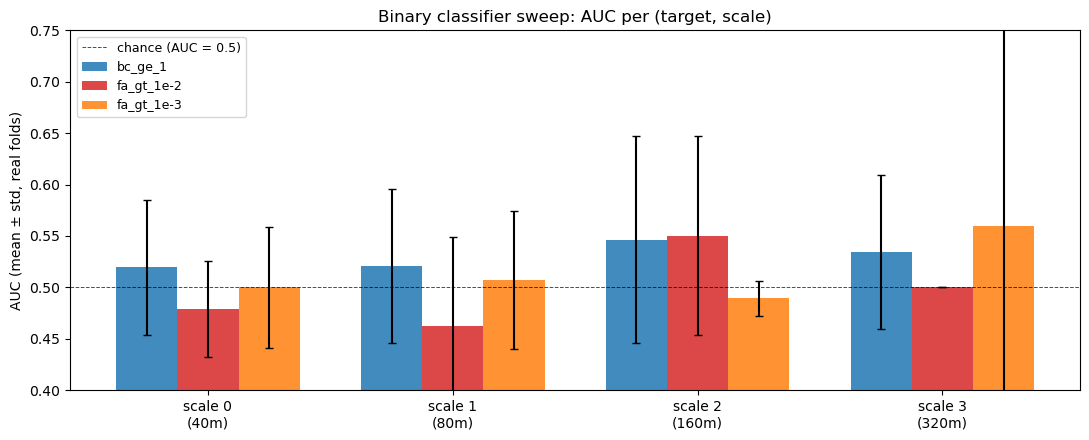

In [12]:
# Bar chart: AUC mean +/- std per (target, scale)
fig, ax = plt.subplots(figsize=(11, 4.5))
scales_b = sorted(bin_aggregate['scale_idx'].unique())
targets_b = sorted(bin_aggregate['target_id'].unique())
x_base = np.arange(len(scales_b))
width = 0.25
target_colors = {'bc_ge_1': 'tab:blue', 'fa_gt_1e-3': 'tab:orange', 'fa_gt_1e-2': 'tab:red'}
for i, t in enumerate(targets_b):
    sub = bin_aggregate[bin_aggregate['target_id'] == t].sort_values('scale_idx')
    # Reindex to align with x_base in case some (target, scale) cells are missing.
    sub = sub.set_index('scale_idx').reindex(scales_b).reset_index()
    means = sub['auc_mean'].to_numpy()
    stds = sub['auc_std'].to_numpy()
    ax.bar(x_base + i * width, means, width, yerr=stds, capsize=3,
           label=t, alpha=0.85, color=target_colors.get(t))
ax.axhline(0.5, color='black', linewidth=0.7, linestyle='--', alpha=0.7,
           label='chance (AUC = 0.5)')
ax.set_xticks(x_base + width)
ax.set_xticklabels([f'scale {s}\n({40 * 2**s:.0f}m)' for s in scales_b])
ax.set_ylabel('AUC (mean ± std, real folds)')
ax.set_ylim(0.4, max(0.75, bin_aggregate['auc_mean'].max() + 0.1))
ax.set_title('Binary classifier sweep: AUC per (target, scale)')
ax.legend(fontsize=9, loc='upper left')
fig.tight_layout()
fig.savefig(FIG_DIR / '10_binary_sweep_auc_bar.png', dpi=110)
plt.show()


### Per-fold AUC by held-out BoulderLabel

Same diagnostic as the regression per-fold-by-label scatter (modeling_results.md
§2.3): does the binary signal track the manifest BoulderLabel of the held-out
image? A Boulder-poor fold with above-chance AUC means the model can recognise
absence well; a Boulder-rich fold with strong AUC means it can recognise
presence well; uniform results across labels means the model's discrimination
is not class-conditional.


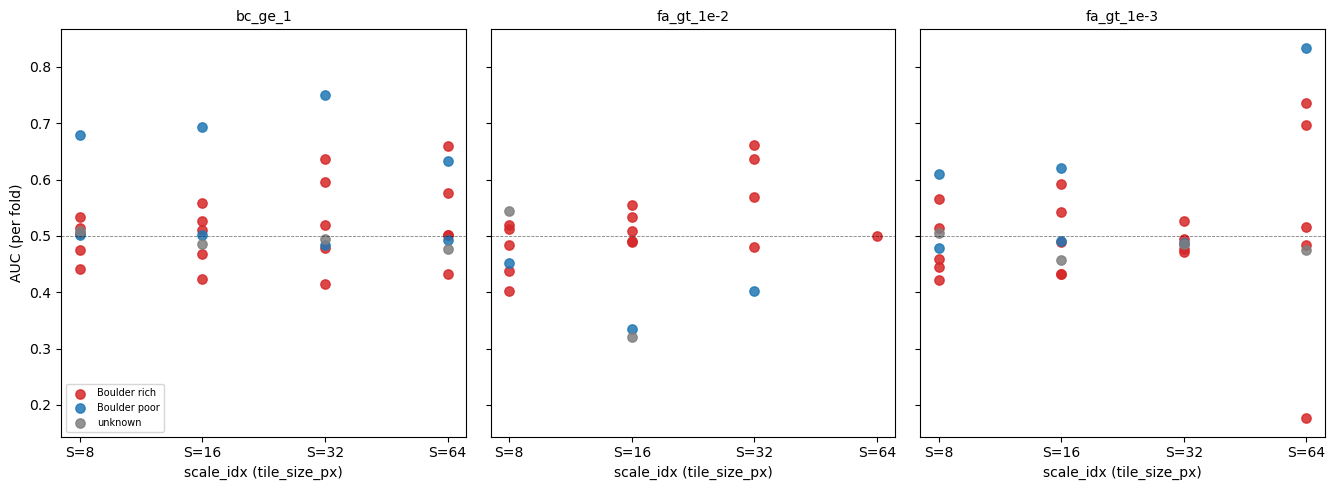

In [13]:
fig, axes = plt.subplots(1, len(targets_b), figsize=(4.5 * len(targets_b), 5), sharey=True, squeeze=False)
for ax, t in zip(axes[0], targets_b):
    sub = bin_summary[(bin_summary['target_id'] == t) & (~bin_summary['is_specificity_only'])]
    label_colors = {'Boulder rich': 'tab:red', 'Boulder poor': 'tab:blue',
                    'unknown': 'tab:gray', 'empty': 'black'}
    for lbl, color in label_colors.items():
        sl = sub[sub['boulder_label'] == lbl]
        if sl.empty: continue
        ax.scatter(sl['scale_idx'], sl['auc'], color=color, alpha=0.85, label=lbl, s=45)
    ax.axhline(0.5, color='black', linewidth=0.6, linestyle='--', alpha=0.5)
    ax.set_xticks(sorted(sub['scale_idx'].unique()))
    ax.set_xticklabels([f'S={2**(3+s)}' for s in sorted(sub['scale_idx'].unique())])
    ax.set_xlabel('scale_idx (tile_size_px)')
    if ax is axes[0][0]:
        ax.set_ylabel('AUC (per fold)')
        ax.legend(fontsize=7, loc='lower left')
    ax.set_title(t, fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / '10_binary_per_fold_auc_by_label.png', dpi=110)
plt.show()


### Calibration plot — best (target, scale) per target

A perfectly calibrated classifier has `mean_pred == mean_true` in every
predicted-probability decile (the diagonal). The auto `scale_pos_weight = neg/pos`
default is essential for the rare-positive targets but can push predicted
probabilities above empirical rates — the calibration plot makes that drift
visible.


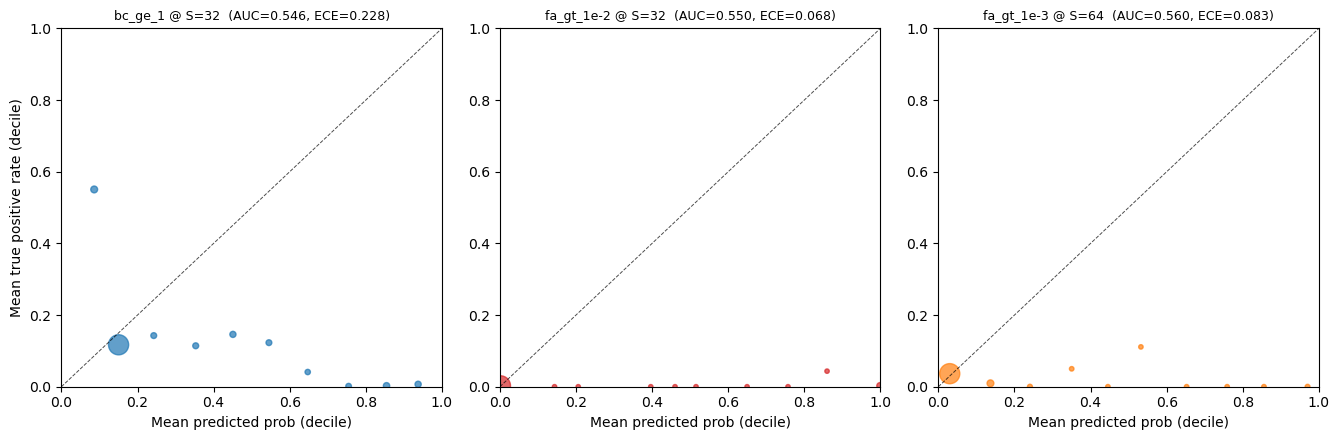

In [14]:
# Per-target: pick the scale with the highest AUC mean and plot its calibration deciles
fig, axes = plt.subplots(1, len(targets_b), figsize=(4.5 * len(targets_b), 4.5), squeeze=False)
for ax, t in zip(axes[0], targets_b):
    sub = bin_aggregate[bin_aggregate['target_id'] == t]
    if sub.empty:
        continue
    best = sub.loc[sub['auc_mean'].idxmax()]
    tile = int(best['tile_size_px'])
    scale_dirs = sorted((MODELS_ROOT / 'lightgbm_classification').glob(f'*/scale_S{tile}_t{t}'),
                        key=lambda p: p.stat().st_mtime)
    if not scale_dirs:
        ax.set_title(f'{t} S={tile} (no metrics.json found)')
        continue
    m = json.loads((scale_dirs[-1] / 'metrics.json').read_text())
    # Concatenate calibration deciles across folds, re-aggregate
    all_deciles = []
    for f in m['per_fold']:
        for d in f.get('calibration_deciles', []):
            if d['n'] > 0:
                all_deciles.append(d)
    if not all_deciles:
        ax.set_title(f'{t} S={tile} (no decile data)')
        continue
    df = pd.DataFrame(all_deciles)
    # Aggregate: sum n, weighted mean of mean_pred and mean_true per bin
    grouped = df.groupby('bin_idx').apply(lambda g: pd.Series({
        'mean_pred': np.average(g['mean_pred'], weights=g['n']),
        'mean_true': np.average(g['mean_true'], weights=g['n']),
        'n_total': g['n'].sum(),
    })).reset_index()
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.7, alpha=0.7, label='perfect calibration')
    ax.scatter(grouped['mean_pred'], grouped['mean_true'],
                s=grouped['n_total'] / grouped['n_total'].max() * 200 + 10,
                alpha=0.7, color=target_colors.get(t, 'tab:purple'))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Mean predicted prob (decile)')
    if ax is axes[0][0]:
        ax.set_ylabel('Mean true positive rate (decile)')
    ax.set_title(f'{t} @ S={tile}  (AUC={best["auc_mean"]:.3f}, ECE={best["ece_mean"]:.3f})', fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / '10_binary_calibration.png', dpi=110)
plt.show()


### Head-to-head: binary classifier AUC vs regression two-stage presence AUC

The regression two-stage hurdle model trains a presence classifier internally
(positive rule `fractional_area > 0`, very close to `bc_ge_1`). Comparing the
dedicated `lightgbm_classification` AUC against the embedded two-stage presence
AUC at matched scales answers the "is dedicated training better than embedded?"
question raised in PLAN_Stage5b.md §11 q1.


In [15]:
# bc_ge_1 vs lightgbm_two_stage presence_auc
bc = bin_aggregate[bin_aggregate['target_id'] == 'bc_ge_1'][
    ['scale_idx', 'tile_size_px', 'auc_mean', 'auc_std']
].rename(columns={'auc_mean': 'classifier_auc_mean', 'auc_std': 'classifier_auc_std'})
ts = aggregate[aggregate['variant'] == 'lightgbm_two_stage'][
    ['scale_idx', 'tile_size_px', 'presence_auc_mean', 'presence_auc_std']
].rename(columns={'presence_auc_mean': 'two_stage_presence_auc_mean',
                   'presence_auc_std': 'two_stage_presence_auc_std'})
head_to_head = bc.merge(ts, on=['scale_idx', 'tile_size_px']).sort_values('scale_idx')
for c in ('classifier_auc_mean', 'classifier_auc_std',
          'two_stage_presence_auc_mean', 'two_stage_presence_auc_std'):
    head_to_head[c] = head_to_head[c].round(4)
head_to_head


,scale_idx,tile_size_px,classifier_auc_mean,classifier_auc_std,two_stage_presence_auc_mean,two_stage_presence_auc_std


### Lift at top-k

`lift_at_top_k` = precision in the top-k predicted-probability tiles, where
k = number of true positives in the fold, divided by the base rate. A random
classifier has lift = 1; a perfect classifier has lift = 1 / base_rate. Lift
> 1 means the model's top-ranked tiles are enriched in real positives.


In [16]:
lift_table = bin_aggregate[['target_id', 'scale_idx', 'tile_size_px',
                                   'lift_at_top_k_mean', 'lift_at_top_k_std']].copy()
for c in ('lift_at_top_k_mean', 'lift_at_top_k_std'):
    lift_table[c] = lift_table[c].round(3)
lift_table.sort_values(['scale_idx', 'target_id'])


,target_id,scale_idx,tile_size_px,lift_at_top_k_mean,lift_at_top_k_std
0,bc_ge_1,0,8,0.993,0.456
8,fa_gt_1e-2,0,8,0.263,0.426
4,fa_gt_1e-3,0,8,0.894,0.461
1,bc_ge_1,1,16,0.961,0.561
9,fa_gt_1e-2,1,16,0.188,0.461
5,fa_gt_1e-3,1,16,0.838,0.464
2,bc_ge_1,2,32,0.989,0.559
10,fa_gt_1e-2,2,32,0.000,0.000
6,fa_gt_1e-3,2,32,1.285,1.318
3,bc_ge_1,3,64,0.875,0.450


## Within-image cross-validation (Stage 5c diagnostic)

[PLAN_Stage5c.md](../PLAN_Stage5c.md) frames a single-experiment falsification of the
data-quantity-bound hypothesis: train and test on the **same image** by partitioning each
image's tiles into 2x2 spatial quadrants, then rotate which quadrant is held out. With 8
non-empty images (ESP_065711_1545 excluded) x 4 quadrants = **32 folds per (variant,
scale)** cell.

The diagnostic is binary:

- **Within-image AUC ~= LOIO AUC ~0.55** — the 5 m / pixel CTX texture signal is at its
  per-image ceiling. More HiRISE images would not unlock additional signal at this CTX
  resolution.
- **Within-image AUC >> LOIO AUC (>= 0.7)** — per-image generalisation is the binding
  constraint. The model has learned per-image structure that does not transfer; more
  HiRISE images, especially geographically diverse ones, are the unlock.

Variants run: [`lightgbm_two_stage`](../src/modeling/gbm.py) (best LOIO regression
Spearman at S=64) and [`lightgbm_classification`](../src/modeling/gbm.py) at
[`bc_ge_1`](../src/modeling/binary_target.py) (best LOIO binary AUC at S=32 / S=64).
Both with the same Stage 5b LightGBM defaults; only the split scheme changes.

Statistical comparison: paired per-image deltas `within_image_AUC - LOIO_AUC` give
8 paired observations per (variant, scale). Report the mean delta, a bootstrap 95 % CI,
and a Wilcoxon signed-rank p-value (the natural significance check for paired
deltas with no normality assumption).


In [17]:
# Load the most-recent within-image sweep.
within_dirs = sorted((MODELS_ROOT / '_sweep_within_image').glob('*/'))
assert within_dirs, 'no models/_sweep_within_image/* runs found -- run scripts/sweep_within_image.py'
WITHIN_DIR = within_dirs[-1]
print(f'within-image sweep dir: {WITHIN_DIR.name}')

within_summary = pd.read_parquet(WITHIN_DIR / 'summary.parquet')
within_aggregate = pd.read_parquet(WITHIN_DIR / 'aggregate.parquet')
within_per_image = pd.read_parquet(WITHIN_DIR / 'per_image.parquet')
print(f'within-image rows: summary={len(within_summary)}, '
      f'aggregate={len(within_aggregate)}, per_image={len(within_per_image)}')
print(f'  variants:      {sorted(within_summary["variant"].unique().tolist())}')
print(f'  scale_idx:     {sorted(within_summary["scale_idx"].unique().tolist())}')
print(f'  n_folds:       {within_summary.groupby(["variant", "scale_idx"]).size().iloc[0]}')


within-image sweep dir: 20260527T175437Z
within-image rows: summary=256, aggregate=8, per_image=64
  variants:      ['lightgbm_classification', 'lightgbm_two_stage']
  scale_idx:     [0, 1, 2, 3]
  n_folds:       32


In [18]:
# Build the matched LOIO baseline.
#   - lightgbm_two_stage  -> LOIO regression sweep (presence_auc per fold)
#   - lightgbm_classification @ bc_ge_1 -> LOIO binary sweep (auc per fold)
# Both flatten to ('variant', 'scale_idx', 'held_out_obs_id', 'auc') for the comparison.
#
# We pick the most recent _sweep/* directory that actually contains
# lightgbm_two_stage rows (the latest single-variant re-runs would be missed by a
# naive sweep_dirs[-1] selection).
def _pick_full_loio_sweep():
    for d in sorted((MODELS_ROOT / '_sweep').glob('*/'), key=lambda p: p.stat().st_mtime, reverse=True):
        if 'lightgbm_two_stage' in pd.read_parquet(d / 'summary.parquet')['variant'].unique():
            return d
    raise FileNotFoundError('No LOIO sweep contains lightgbm_two_stage rows')
LOIO_FOR_DELTA = _pick_full_loio_sweep()
print(f'LOIO baseline sweep: {LOIO_FOR_DELTA.name}')
loio_summary = pd.read_parquet(LOIO_FOR_DELTA / 'summary.parquet')

loio_two_stage = (
    loio_summary[loio_summary['variant'] == 'lightgbm_two_stage']
    [['variant', 'scale_idx', 'tile_size_px', 'held_out_obs_id',
      'presence_auc', 'spearman_rho', 'is_specificity_only']]
    .rename(columns={'presence_auc': 'auc'})
)
loio_classifier = (
    bin_summary[bin_summary['target_id'] == 'bc_ge_1']
    [['scale_idx', 'tile_size_px', 'held_out_obs_id', 'auc', 'is_specificity_only']]
    .assign(variant='lightgbm_classification', spearman_rho=np.nan)
)
loio_baseline = pd.concat([loio_two_stage, loio_classifier], ignore_index=True)
print('LOIO baseline rows:', len(loio_baseline))
loio_baseline.head()


LOIO baseline sweep: 20260524T071830Z
LOIO baseline rows: 72


,variant,scale_idx,tile_size_px,held_out_obs_id,auc,spearman_rho,is_specificity_only
0,lightgbm_two_stage,0,8,ESP_039820_1750,0.553571,0.016987,False
1,lightgbm_two_stage,0,8,ESP_047976_2020,0.439668,-0.027747,False
2,lightgbm_two_stage,0,8,ESP_054857_2270,0.523995,0.029399,False
3,lightgbm_two_stage,0,8,ESP_055714_2270,0.442015,-0.026572,False
4,lightgbm_two_stage,0,8,ESP_056165_2200,0.605222,0.006993,False


### Headline: mean(within_image_AUC - LOIO_AUC) per (variant, scale)

The single number that answers PLAN_Stage5c.md's diagnostic. Each row's delta is the
mean across the 8 non-empty images of `(within_image_AUC_for_that_image -
LOIO_AUC_for_that_image)`. Bootstrap CI is non-parametric (10000 resamples of the 8
paired deltas with replacement); Wilcoxon signed-rank p-value tests `H_0: median
delta = 0`.

For `lightgbm_classification`, "AUC" is the standard ROC AUC of `bc_ge_1` truth vs.
predicted probability. For `lightgbm_two_stage`, "AUC" is the **presence_auc** from
the regression sweep -- the same Mann-Whitney U statistic applied to `y_true > 0` vs.
the model's continuous output, which is the closest analogue to the classifier's
ROC AUC.


In [19]:
from scipy import stats

def per_image_within_minus_loio(variant, scale_idx, n_bootstrap=10_000, rng_seed=0):
    rng = np.random.default_rng(rng_seed)
    # Per-image within-image AUC: average the variant's 4 quadrant folds. For
    # two_stage we average presence_auc; for classification we average auc.
    auc_col = 'presence_auc' if variant == 'lightgbm_two_stage' else 'auc'
    sub = within_summary[
        (within_summary['variant'] == variant)
        & (within_summary['scale_idx'] == scale_idx)
        & (~within_summary['is_specificity_only'].astype(bool))
    ]
    w = sub.groupby('held_out_obs_id').agg(
        within_auc=(auc_col, 'mean'),
        n_real_folds=('fold_idx', 'count'),
    ).reset_index()
    # LOIO baseline: one AUC per image (one fold per image).
    lo = loio_baseline[
        (loio_baseline['variant'] == variant)
        & (loio_baseline['scale_idx'] == scale_idx)
        & (~loio_baseline['is_specificity_only'].astype(bool))
    ][['held_out_obs_id', 'auc']].rename(columns={'auc': 'loio_auc'})
    paired = w.merge(lo, on='held_out_obs_id', how='inner')
    paired['delta'] = paired['within_auc'] - paired['loio_auc']
    n = len(paired)
    if n < 2:
        return paired, dict(n=n, mean_delta=float('nan'), ci_lo=float('nan'),
                            ci_hi=float('nan'), wilcoxon_p=float('nan'))
    delta = paired['delta'].to_numpy()
    mean_delta = float(delta.mean())
    boots = rng.choice(delta, size=(n_bootstrap, n), replace=True).mean(axis=1)
    ci_lo, ci_hi = float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))
    if (delta == 0).all():
        wp = float('nan')
    else:
        wp = float(stats.wilcoxon(delta, alternative='two-sided').pvalue)
    return paired, dict(n=n, mean_delta=mean_delta, ci_lo=ci_lo, ci_hi=ci_hi, wilcoxon_p=wp)

variants_in_sweep = sorted(within_summary['variant'].unique().tolist())
scales_in_sweep = sorted(within_summary['scale_idx'].unique().tolist())
rows = []
all_paired = {}
for v in variants_in_sweep:
    for s in scales_in_sweep:
        paired, stat = per_image_within_minus_loio(v, s)
        all_paired[(v, s)] = paired
        rows.append({
            'variant': v, 'scale_idx': s, 'tile_size_px': int(2 ** (3 + s)),
            **stat,
        })
delta_table = pd.DataFrame(rows)
for c in ('mean_delta', 'ci_lo', 'ci_hi', 'wilcoxon_p'):
    delta_table[c] = delta_table[c].round(4)
delta_table.sort_values(['variant', 'scale_idx'])


,variant,scale_idx,tile_size_px,n,mean_delta,ci_lo,ci_hi,wilcoxon_p
0,lightgbm_classification,0,8,8,-0.0013,-0.0533,0.0350,0.3828
1,lightgbm_classification,1,16,8,0.0111,-0.0550,0.0580,0.3828
2,lightgbm_classification,2,32,8,-0.0046,-0.0936,0.0593,0.6406
3,lightgbm_classification,3,64,8,0.0365,-0.0236,0.0996,0.3828
4,lightgbm_two_stage,0,8,8,0.0156,-0.0178,0.0510,0.6406
5,lightgbm_two_stage,1,16,8,0.0218,-0.0186,0.0582,0.3125
6,lightgbm_two_stage,2,32,8,0.0303,-0.0178,0.0847,0.4609
7,lightgbm_two_stage,3,64,8,0.0100,-0.0918,0.0983,0.7422


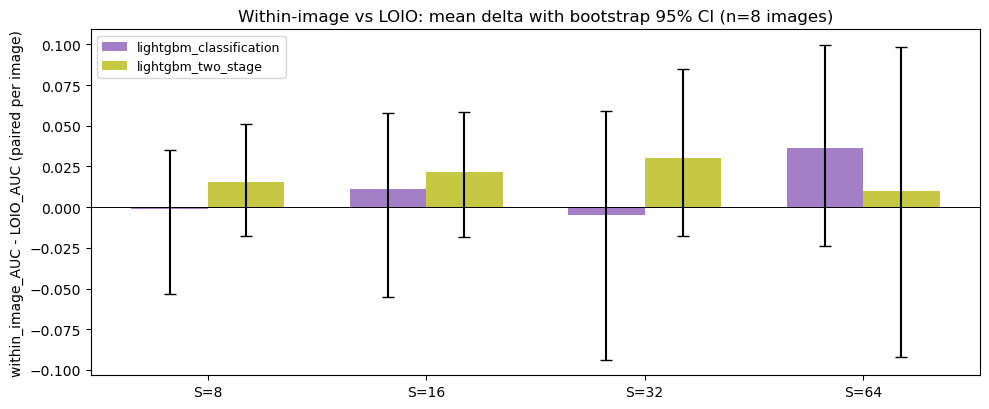

In [20]:
# Bar chart: mean delta with 95% CI per (variant, scale).
fig, ax = plt.subplots(figsize=(10, 4.2))
x_base = np.arange(len(scales_in_sweep))
width = 0.35
variant_colors = {'lightgbm_two_stage': 'tab:olive', 'lightgbm_classification': 'tab:purple'}
for i, v in enumerate(variants_in_sweep):
    sub = delta_table[delta_table['variant'] == v].sort_values('scale_idx')
    means = sub['mean_delta'].to_numpy()
    ci_lo = sub['ci_lo'].to_numpy()
    ci_hi = sub['ci_hi'].to_numpy()
    err = np.stack([means - ci_lo, ci_hi - means])
    ax.bar(x_base + (i - 0.5) * width, means, width, yerr=err, capsize=4,
            color=variant_colors.get(v, 'gray'), alpha=0.85, label=v)
ax.axhline(0, color='black', linewidth=0.7)
ax.set_xticks(x_base)
ax.set_xticklabels([f'S={int(2 ** (3 + s))}' for s in scales_in_sweep])
ax.set_ylabel('within_image_AUC - LOIO_AUC (paired per image)')
ax.set_title(f'Within-image vs LOIO: mean delta with bootstrap 95% CI (n=8 images)')
ax.legend(fontsize=9, loc='best')
fig.tight_layout()
fig.savefig(FIG_DIR / '10_within_image_delta_bar.png', dpi=110)
plt.show()


### Per-image AUC: within-image (mean of 4 quadrants) vs LOIO

Grouped bar chart showing, for each image, the within-image AUC (averaged across its
4 spatial quadrant folds) alongside the LOIO AUC for that same image. The visual
question is: do bars *systematically* lift above the LOIO baseline, or do
within-image folds sit roughly on top of LOIO?

Boulder-poor images (`ESP_056165_2200`, `ESP_075577_2105`) and the unknown image
(`ESP_039820_1750`) have very few positives per quadrant, so their within-image bars
carry more sampling noise than the Boulder-rich images.


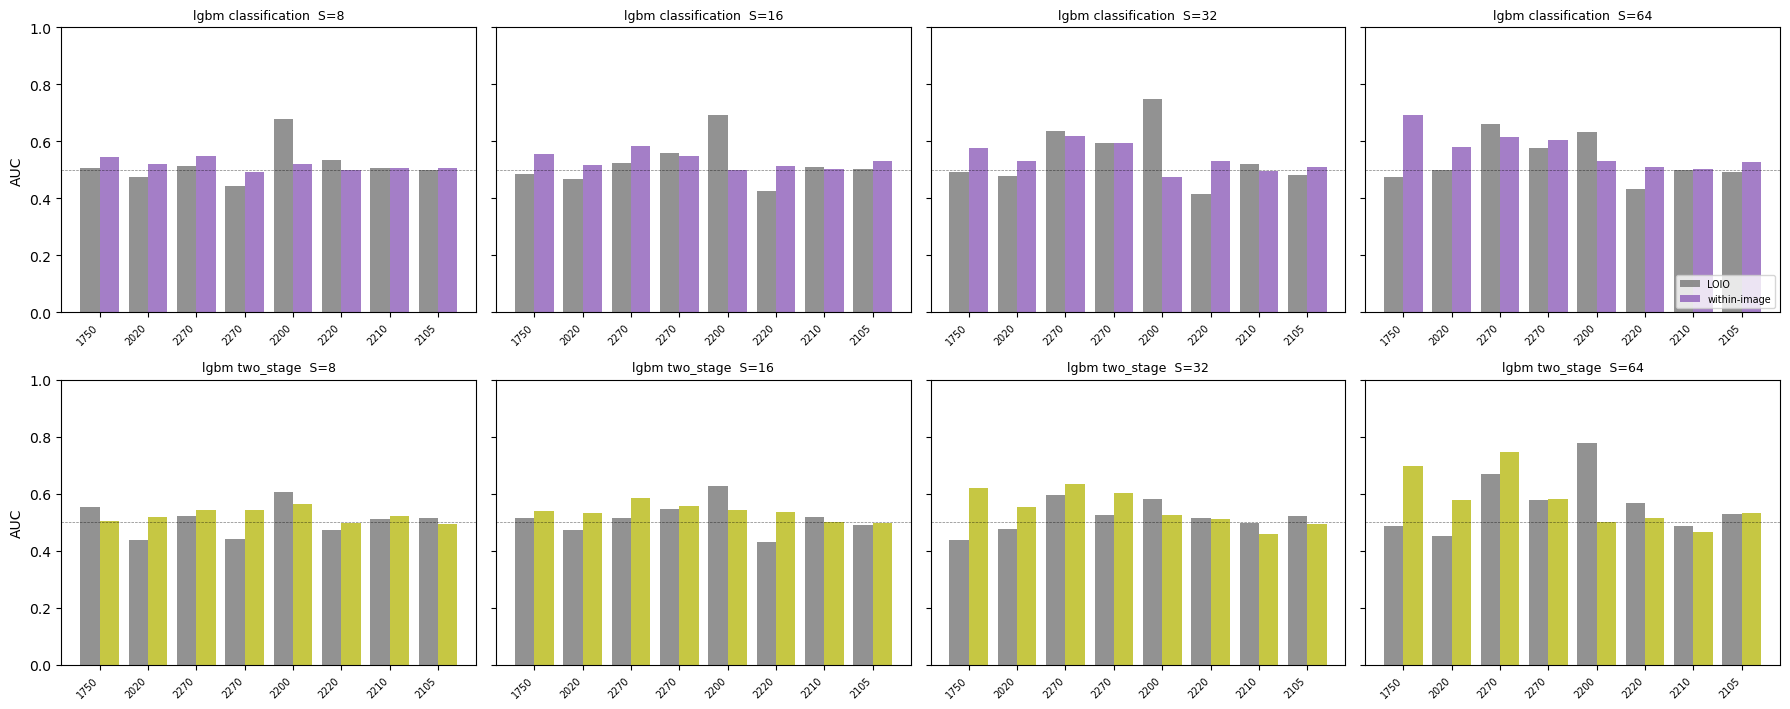

In [21]:
# Per-image AUC bar chart: paired within-image vs LOIO, one panel per (variant, scale).
fig, axes = plt.subplots(
    len(variants_in_sweep), len(scales_in_sweep),
    figsize=(4.5 * len(scales_in_sweep), 3.6 * len(variants_in_sweep)),
    sharey=True, squeeze=False,
)
for i, v in enumerate(variants_in_sweep):
    for j, s in enumerate(scales_in_sweep):
        ax = axes[i][j]
        paired = all_paired[(v, s)].sort_values('held_out_obs_id')
        if paired.empty:
            ax.set_title(f'{v} S={int(2 ** (3 + s))}\n(no data)', fontsize=8)
            continue
        x = np.arange(len(paired))
        ax.bar(x - 0.2, paired['loio_auc'], 0.4, label='LOIO', color='tab:gray', alpha=0.85)
        ax.bar(x + 0.2, paired['within_auc'], 0.4, label='within-image',
               color=variant_colors.get(v, 'tab:purple'), alpha=0.85)
        ax.axhline(0.5, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels([oid[-4:] for oid in paired['held_out_obs_id']], rotation=45, ha='right', fontsize=7)
        ax.set_ylim(0, 1)
        ax.set_title(f'{v.replace("lightgbm_", "lgbm ")}  S={int(2 ** (3 + s))}', fontsize=9)
        if j == 0:
            ax.set_ylabel('AUC')
        if i == 0 and j == len(scales_in_sweep) - 1:
            ax.legend(fontsize=7, loc='lower right')
fig.tight_layout()
fig.savefig(FIG_DIR / '10_within_image_per_image_bar.png', dpi=110)
plt.show()


### Diagnostic verdict

The structural read of the deltas:

- **If `mean_delta` is small and bracketed by zero (CI spans 0):** within-image and
  LOIO see the same per-image signal; the 5 m / pixel CTX texture floor is the
  binding constraint. *Adding more HiRISE images would not unlock additional
  per-tile signal at this CTX resolution*. Other recommendations (CNN loss fix,
  THEMIS validation, two-stage calibration) move into priority position.
- **If `mean_delta` is positive at multiple scales, CI excludes 0, Wilcoxon p < 0.05:**
  per-image generalisation is the binding constraint. *Geographically diverse HiRISE
  images are the unlock.* Adding 9 -> 18 images would halve the per-fold standard
  error and likely move AUC into the 0.6+ range that the existing modelling stack
  can support.

The verdict — and the recommendation update it implies — is captured in
[`docs/modeling_results.md`](../docs/modeling_results.md) §7.


## Spatial pred-vs-truth diagnostic

Every other figure in this notebook is *scalar*: mean Spearman, mean AUC, per-fold
distribution, decile calibration, predicted-vs-true scatter on log-log axes. None
of them answers the spatial question:

> Given an image the model has never seen, where on that image does the
> model think the boulders are, and how does that compare to where the
> BoulderNet polygons actually sit?

This section renders one row per held-out image with three CTX-anchored panels in
matched world (metre) coordinates:

1. **Truth** — per-tile `fractional_area` (Stage 4 ground-truth from BoulderNet
   polygons rasterised onto the CTX grid).
2. **Regression prediction** — `lightgbm_two_stage` LOIO `y_pred` at S=64
   (best-Spearman cell, modeling_results.md §1).
3. **Classifier probability** — `lightgbm_classification` @ `bc_ge_1` LOIO predicted
   probability at S=64.

All three panels show the **decimated CTX window** as the greyscale background and
overlay the **reprojected BoulderNet detection polygons** as lime outlines, so the
true boulder *positions* (not just per-tile aggregate counts) are visible. Because
each panel uses LOIO predictions, the model has been trained on the OTHER 8 images
in the priority10 manifest and has never seen the image rendered here — these are
honest held-out spatial predictions, not training-set fits.

The point is qualitative: the scalar AUC ≈ 0.55 result already tells us the model is
weakly above chance. The spatial view tells us *what that weakness looks like* —
whether the model is producing a near-constant abundance everywhere, capturing the
broad envelope but missing the high-abundance clusters, or hallucinating boulders in
empty regions.


In [22]:
import rasterio
import geopandas as gpd
from matplotlib.colors import LogNorm, Normalize

# Locate the canonical LOIO prediction artifacts for the two model variants whose
# spatial output we want to inspect. Each (variant, scale) writes to its own
# config_hash dir; glob across hashes and pick most-recent.
def _latest_pred_path(variant: str, scale_px: int, suffix: str = '') -> Path:
    pat = f'*/scale_S{scale_px}{suffix}/predictions.parquet'
    candidates = sorted((MODELS_ROOT / variant).glob(pat),
                        key=lambda p: p.stat().st_mtime)
    if not candidates:
        raise FileNotFoundError(f'no predictions matching {variant}/{pat}')
    return candidates[-1]

REG_S64_PATH = _latest_pred_path('lightgbm_two_stage', 64)
CLS_S64_PATH = _latest_pred_path('lightgbm_classification', 64, suffix='_tbc_ge_1')
print(f'regression  preds: {REG_S64_PATH.relative_to(REPO_ROOT)}')
print(f'classifier  preds: {CLS_S64_PATH.relative_to(REPO_ROOT)}')

reg_preds_all = pd.read_parquet(REG_S64_PATH)
cls_preds_all = pd.read_parquet(CLS_S64_PATH)
print(f'reg preds rows: {len(reg_preds_all):,}  cls preds rows: {len(cls_preds_all):,}')

# Restrict the iteration to ObsIds that actually have Stage 4 / 4b artifacts on disk.
# The priority10 manifest carries ESP_057469_2215 which was dropped from the Stage 4
# sweep upstream (multi-tile straddle; DECISIONS.md 2026-05-22) -- without this filter,
# the spatial panels would try to load a missing labels parquet and crash.
_LABELS_DIR = REPO_ROOT / 'dataset' / 'labels'
_HAVE_LABELS = {p.stem for p in _LABELS_DIR.glob('*.parquet')}
print(f'images with labels on disk: {len(_HAVE_LABELS)}')


regression  preds: models\lightgbm_two_stage\8ce4b88b0aad10e9\scale_S64\predictions.parquet
classifier  preds: models\lightgbm_classification\3f56a95f1ac22ab8\scale_S64_tbc_ge_1\predictions.parquet
reg preds rows: 6,587  cls preds rows: 6,587
images with labels on disk: 9


In [23]:
def _grid_for_image(df, value_col):
    """Build a 2-D (ti, tj) grid + its world-coordinate extent.

    Caller is responsible for filtering to a single tile_size_px first. Returns
    (grid, extent) where extent = (x_lo, x_hi, y_lo, y_hi) in CTX-mosaic metres.
    Tiles outside the HiRISE footprint are absent from `df` and appear as NaN in
    the grid (matplotlib renders NaN as transparent under most colormaps).
    """
    sub = df
    if sub.empty:
        return None, None
    ti_min, ti_max = int(sub['ti'].min()), int(sub['ti'].max())
    tj_min, tj_max = int(sub['tj'].min()), int(sub['tj'].max())
    grid = np.full((ti_max - ti_min + 1, tj_max - tj_min + 1), np.nan, dtype=np.float64)
    grid[sub['ti'].to_numpy() - ti_min, sub['tj'].to_numpy() - tj_min] = sub[value_col].to_numpy()
    x_lo = float(sub['xmin'].min())
    x_hi = float(sub['xmax'].max())
    y_lo = float(sub['ymin'].min())
    y_hi = float(sub['ymax'].max())
    return grid, (x_lo, x_hi, y_lo, y_hi)


def _render_panel(ax, ctx_arr, ctx_extent, value_grid, value_extent, polys,
                   *, title, norm, cmap, cbar_label, fig):
    """One panel: CTX greyscale background + tile-level heatmap overlay + polygon outlines."""
    # CTX background: clip to 1st/99th percentile to keep the dynamic range readable.
    p1, p99 = np.percentile(ctx_arr[ctx_arr > 0], [1, 99]) if (ctx_arr > 0).any() else (0, 255)
    ax.imshow(ctx_arr, extent=ctx_extent, cmap='gray', vmin=p1, vmax=p99,
              origin='upper', interpolation='nearest', aspect='equal')
    if value_grid is not None:
        im = ax.imshow(value_grid, extent=value_extent, cmap=cmap, norm=norm,
                       alpha=0.62, origin='upper', interpolation='nearest', aspect='equal')
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        cbar.set_label(cbar_label, fontsize=8)
        cbar.ax.tick_params(labelsize=7)
    if polys is not None and not polys.empty:
        polys.plot(ax=ax, facecolor='none', edgecolor='lime', linewidth=0.25, alpha=0.6)
    ax.set_xlim(ctx_extent[0], ctx_extent[1])
    ax.set_ylim(ctx_extent[2], ctx_extent[3])
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])


def render_image_row(obs_id, fig, axes_row, *, tile_size_px=64):
    """Render the (truth, regression pred, classifier prob) row for one ObsId."""
    labels = pd.read_parquet(REPO_ROOT / 'dataset' / 'labels' / f'{obs_id}.parquet')
    sub = labels[labels['tile_size_px'] == tile_size_px][
        ['ti', 'tj', 'xmin', 'ymin', 'xmax', 'ymax', 'fractional_area']
    ].copy()

    with rasterio.open(REPO_ROOT / 'cache' / 'ctx_windows' / f'{obs_id}.tif') as r:
        ctx_arr = r.read(1)
        ctx_extent = (r.bounds.left, r.bounds.right, r.bounds.bottom, r.bounds.top)

    polys_path = REPO_ROOT / 'cache' / 'reprojected_detections' / f'{obs_id}.gpkg'
    polys = gpd.read_file(polys_path) if polys_path.exists() else None

    truth_grid, truth_ext = _grid_for_image(sub, 'fractional_area')
    has_pos = (sub['fractional_area'] > 0).any()
    truth_norm = LogNorm(vmin=max(sub.loc[sub['fractional_area'] > 0, 'fractional_area'].min(), 1e-5),
                         vmax=max(sub['fractional_area'].max(), 1e-4)) if has_pos else Normalize(vmin=0, vmax=1)

    reg = reg_preds_all[(reg_preds_all['obs_id'] == obs_id) & (reg_preds_all['tile_size_px'] == tile_size_px)]
    reg = reg.merge(sub[['ti', 'tj', 'xmin', 'ymin', 'xmax', 'ymax']], on=['ti', 'tj'], how='inner')
    reg = reg.assign(reg_val=reg['y_pred'].clip(lower=0))
    reg_grid, reg_ext = _grid_for_image(reg, 'reg_val')
    # Use the same color norm as truth so the two panels are visually comparable.
    reg_norm = truth_norm if has_pos else Normalize(vmin=0,
                                                     vmax=max(float(reg['reg_val'].max()), 1e-4))

    cls = cls_preds_all[(cls_preds_all['obs_id'] == obs_id) & (cls_preds_all['tile_size_px'] == tile_size_px)]
    cls = cls.merge(sub[['ti', 'tj', 'xmin', 'ymin', 'xmax', 'ymax']], on=['ti', 'tj'], how='inner')
    cls_grid, cls_ext = _grid_for_image(cls, 'y_pred')
    cls_norm = Normalize(vmin=0.0, vmax=1.0)

    boulder_label = obs_to_label.get(obs_id, 'empty')
    n_polys = 0 if polys is None else len(polys)
    _render_panel(axes_row[0], ctx_arr, ctx_extent, truth_grid, truth_ext, polys,
                   title=f'{obs_id}  ({boulder_label})\nTRUTH fractional_area (S={tile_size_px}, n_polys={n_polys:,})',
                   norm=truth_norm, cmap='inferno', cbar_label='true fractional_area', fig=fig)
    _render_panel(axes_row[1], ctx_arr, ctx_extent, reg_grid, reg_ext, polys,
                   title=f'PRED lightgbm_two_stage\n(LOIO, S={tile_size_px})',
                   norm=reg_norm, cmap='inferno', cbar_label='pred fractional_area', fig=fig)
    _render_panel(axes_row[2], ctx_arr, ctx_extent, cls_grid, cls_ext, polys,
                   title=f'PRED lightgbm_classification @ bc_ge_1\n(LOIO probability, S={tile_size_px})',
                   norm=cls_norm, cmap='viridis', cbar_label='P(boulder)', fig=fig)


### Boulder-rich images (6)

The six images flagged `Boulder rich` in the priority10 manifest. These are the
test set with enough positive tiles for the regression heatmap to have visible
dynamic range. The lime polygons in each panel are the original BoulderNet
detections (reprojected to the CTX mosaic CRS) — small lime dots / clusters
mark individual boulder positions.

What to look at:

- **Spatial agreement between TRUTH and PRED.** Does the predicted-abundance
  pattern follow the truth pattern at the level of broad regions of the image,
  or is it essentially flat with weak per-tile fluctuation?
- **Maximum predicted value.** PLAN_modeling.md §11.2 documented the
  ~10× compression of the GBM's prediction range vs the true range; the
  inferno colorbar uses the truth's log-scale, so a model that compresses
  its predictions into the low end of the truth range will look almost dark
  blue across the entire pred panel.
- **Classifier probability vs. truth.** The classifier panel is on a fixed
  [0, 1] viridis scale and is independent of the regression panel's
  log-norm. Look for whether the high-probability regions (yellow) sit on
  top of polygon-dense regions.


Boulder-rich ObsIds (5): ['ESP_047976_2020', 'ESP_054857_2270', 'ESP_055714_2270', 'ESP_069669_2220', 'ESP_071093_2210']


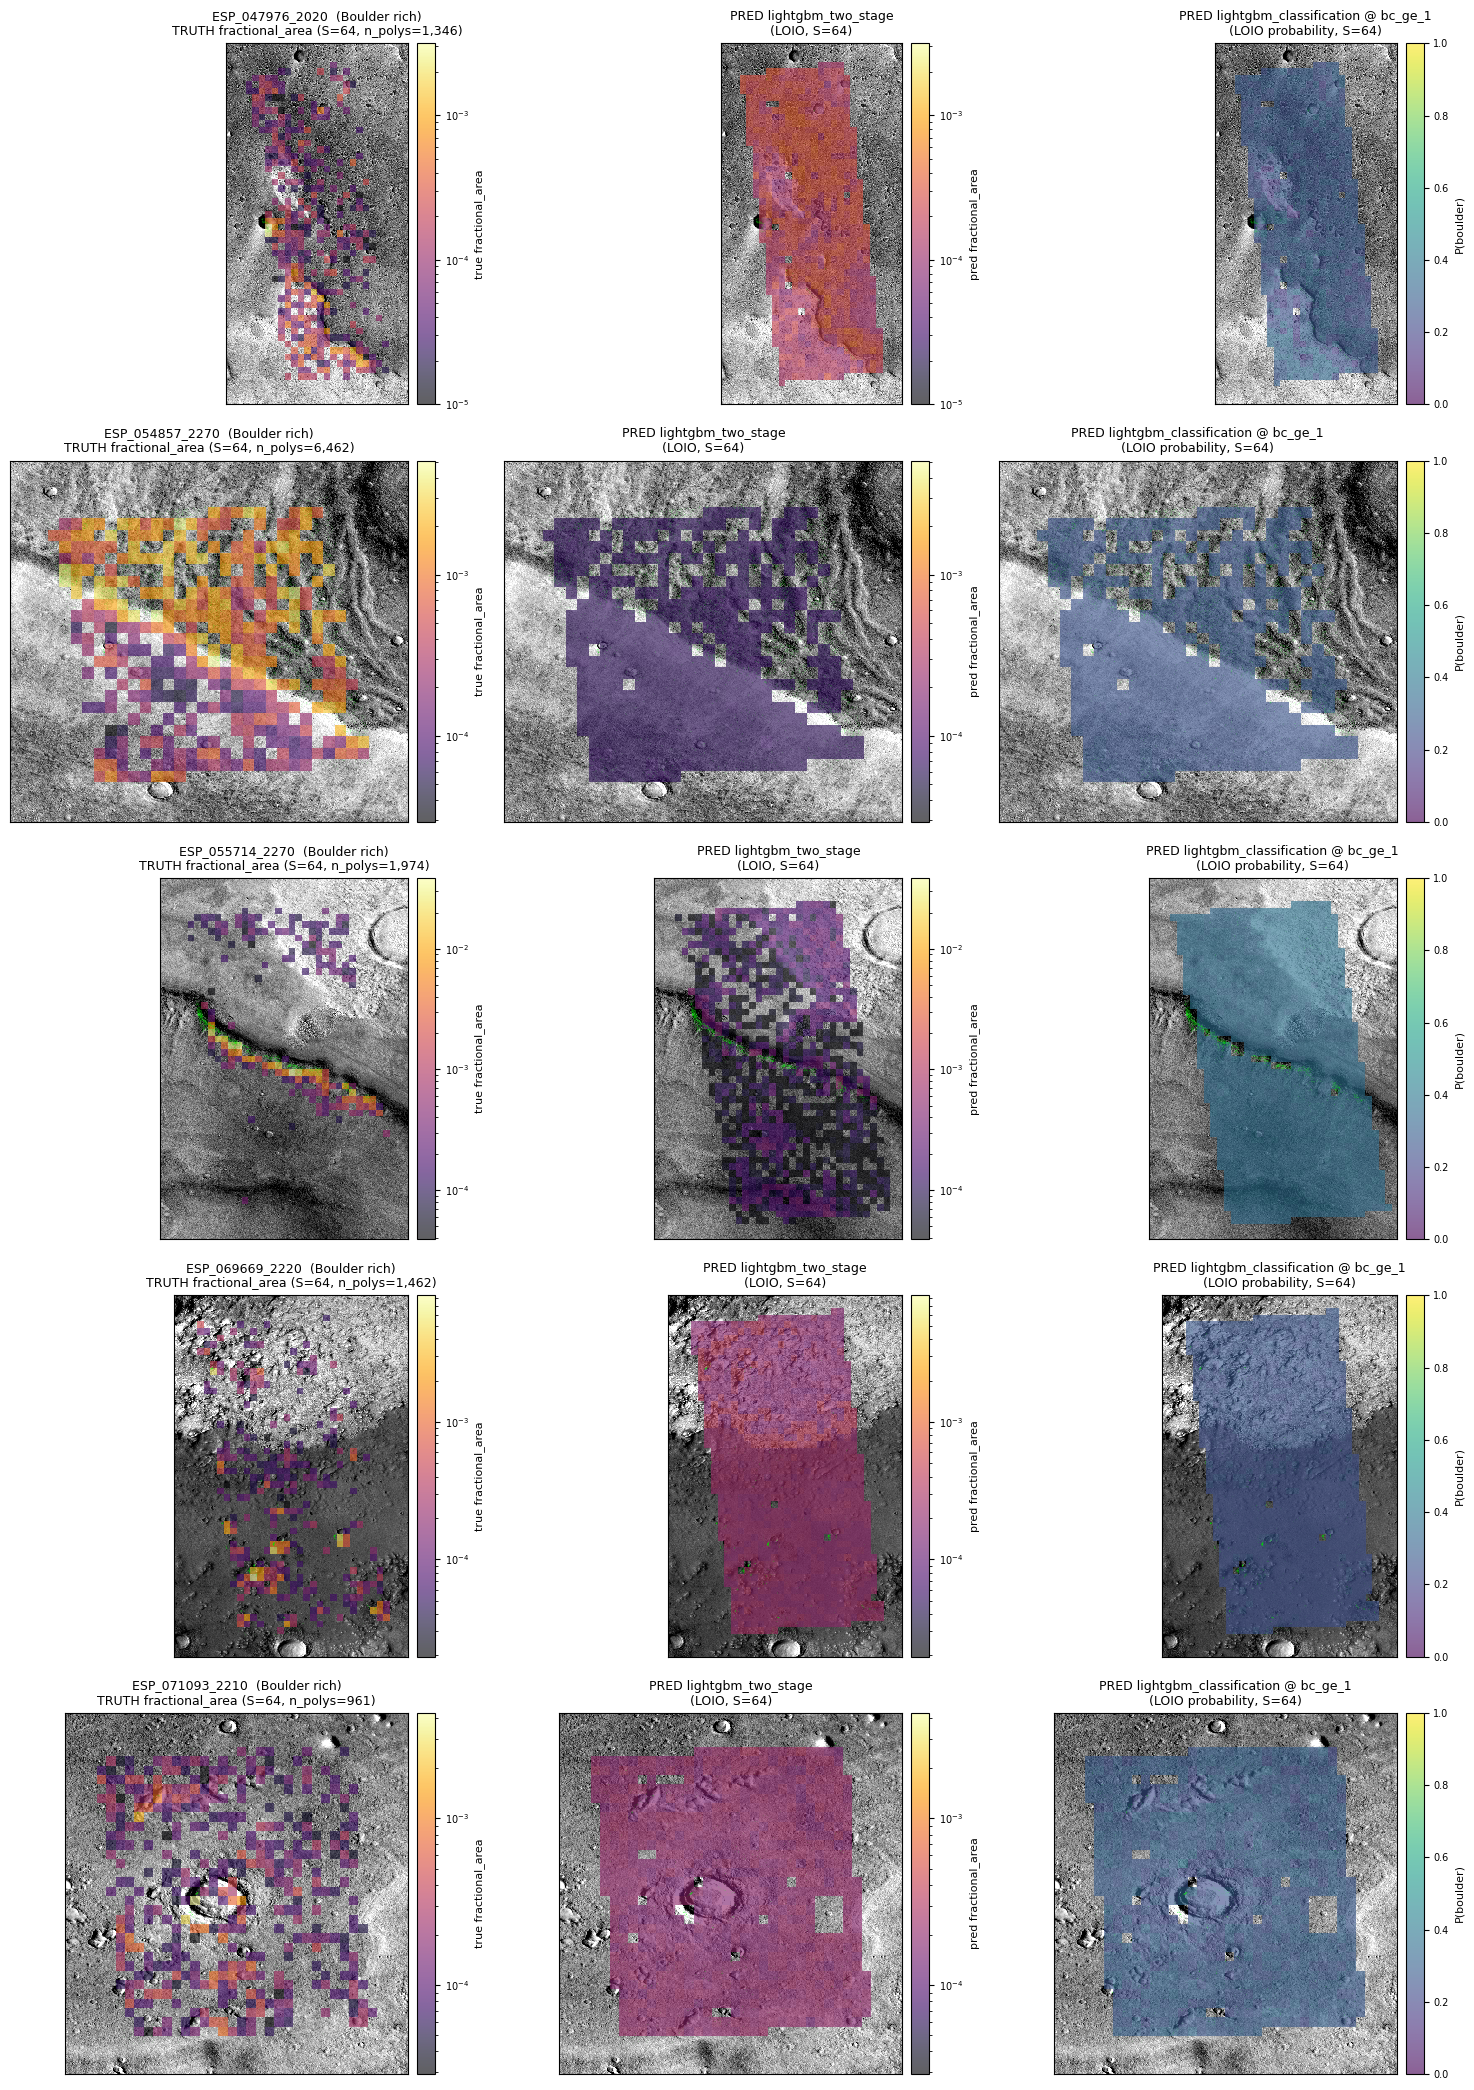

In [24]:
rich_obs = sorted([obs for obs, lbl in obs_to_label.items()
                            if lbl == 'Boulder rich' and obs in _HAVE_LABELS])
print(f'Boulder-rich ObsIds ({len(rich_obs)}):', rich_obs)

fig, axes = plt.subplots(len(rich_obs), 3, figsize=(15, 4.2 * len(rich_obs)),
                          squeeze=False)
for i, obs in enumerate(rich_obs):
    render_image_row(obs, fig, axes[i], tile_size_px=64)
fig.tight_layout()
fig.savefig(FIG_DIR / '10_spatial_pred_vs_truth_rich.png', dpi=120, bbox_inches='tight')
plt.show()


### Boulder-poor + unknown + empty-truth images (3)

Three diagnostic images that stress different failure modes:

- **Boulder-poor (`ESP_056165_2200`, `ESP_075577_2105`)** — few positives per
  image; the regression panel should be near-empty, and the classifier panel
  should show whether the model still flags large regions as high-probability
  (a false-positive failure mode that would not be visible in the AUC because
  the rank ordering can still be roughly correct).
- **Unknown (`ESP_039820_1750`)** — boulder presence not labelled in the
  manifest; visually inspect whether the predictions track the polygon
  density even though the per-image class is uncertain. (BoulderNet was still
  run on this image, so the truth polygons are real.)
- **Empty-truth (`ESP_065711_1545`)** — the no-detections image. Both the
  regression and classifier panels here are pure false-positive maps: any
  non-zero value is the model hallucinating boulders that BoulderNet did
  not find. This is the specificity check that the §6.4 calibration table
  flagged as poor (`scale_pos_weight` inflates predicted probabilities).


Diverse ObsIds (4): ['ESP_039820_1750', 'ESP_056165_2200', 'ESP_065711_1545', 'ESP_075577_2105']


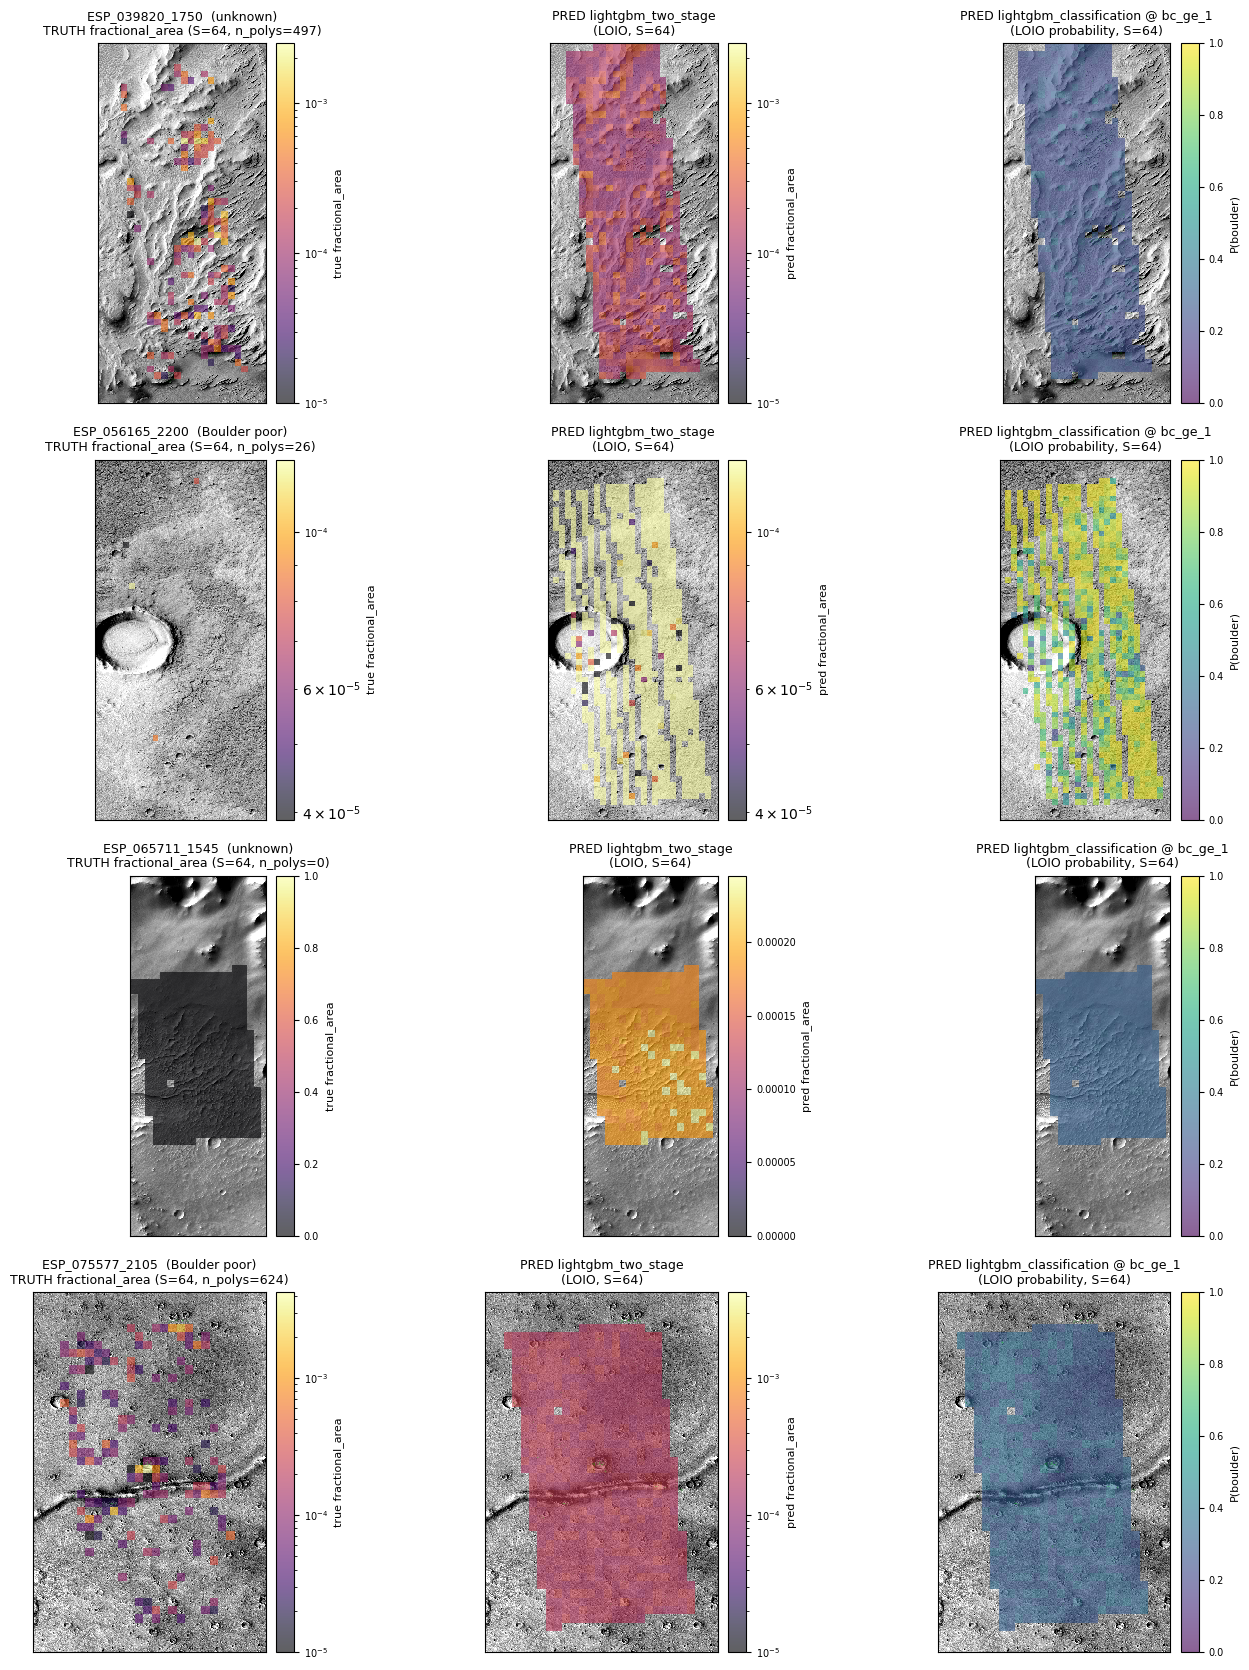

In [25]:
diverse_obs = sorted([obs for obs, lbl in obs_to_label.items()
                              if lbl in ('Boulder poor', 'unknown') and obs in _HAVE_LABELS])
if 'ESP_065711_1545' in _HAVE_LABELS:
    diverse_obs += ['ESP_065711_1545']  # always include the empty-truth image
diverse_obs = list(dict.fromkeys(diverse_obs))  # de-dup, preserve order
print(f'Diverse ObsIds ({len(diverse_obs)}):', diverse_obs)

fig, axes = plt.subplots(len(diverse_obs), 3, figsize=(15, 4.2 * len(diverse_obs)),
                          squeeze=False)
for i, obs in enumerate(diverse_obs):
    render_image_row(obs, fig, axes[i], tile_size_px=64)
fig.tight_layout()
fig.savefig(FIG_DIR / '10_spatial_pred_vs_truth_diverse.png', dpi=120, bbox_inches='tight')
plt.show()


### Reading the spatial diagnostic

The expected pattern given the §1 / §6 / §7 ceiling (AUC ≈ 0.55, Spearman in the
single-digit hundredths):

- **TRUTH** panels show concentrated high-abundance hotspots wherever the
  BoulderNet polygons cluster (the lime dots are dense), plus broad regions of
  zero or near-zero fractional area.
- **REGRESSION PRED** panels predict values an order of magnitude below the
  truth's maximum (the inferno colormap saturates near-black across most of
  the image), but the spatial pattern of where the model places its highest
  predicted abundance does have weak correspondence with the truth hotspots —
  this is the +0.06 Spearman signal made visible spatially.
- **CLASSIFIER PROBABILITY** panels operate on a different scale (probability
  in [0, 1]) and show stronger spatial contrast — bright yellow regions are
  where the classifier confidently flags boulder presence. The fraction of
  yellow on Boulder-poor images (especially `ESP_065711_1545`'s empty-truth
  panel) directly measures false-positive rate; this is the §6.4 calibration
  problem made visible spatially.

This is the figure to cite when an outside reviewer asks "can your model
predict where the boulders are?" — the answer is "yes, weakly, at the
broad-region level, but compresses the dynamic range and produces calibrated
false positives on plains."


## Summary

Per the AskUserQuestion 2026-05-27 + 2026-05-26 decisions, this notebook ships
both regression and binary-classification baselines on the same Stage 5
packaged dataset:

**Regression** (Stage 5 / Week 3 baseline):

- 3 LightGBM variants (`lightgbm_tweedie`, `lightgbm_log1p_huber`, `lightgbm_two_stage`)
  x 4 scales = 12 sweeps, each across 9 LOIO folds. Mean +/- std Spearman, presence
  AUC, per-abundance-bin RMSE, predicted-vs-true scatter, GBM feature importance.
- Small CNN (`cnn_log1p_huber_S32`, `cnn_log1p_huber_S64`) at the matched coarsest
  scales, trained on Stage 4b context patches.

**Binary classification** (Stage 5b reframing):

- New `lightgbm_classification` variant x 3 binary targets (`bc_ge_1`,
  `fa_gt_1e-3`, `fa_gt_1e-2`) x 4 scales = 12 sweeps.
- AUC + Brier + per-decile calibration + lift-at-top-k, same LOIO harness, same
  per-fold-by-BoulderLabel diagnostic + head-to-head comparison to the
  regression two-stage's embedded presence classifier.

Per-fold tagging by BoulderLabel + special handling for the empty-truth fold
(ESP_065711_1545) as a specificity check applies to both halves.

What follow-up phases should focus on (PLAN_modeling.md §10 + §11,
PLAN_Stage5b.md §12 + docs/modeling_results.md §5):

1. **Within-image cross-validation** -- the cheapest decisive test of whether
   the bottleneck is per-image generalisation or signal floor.
2. **More HiRISE images** -- the structural variance unlock; 9 -> 18 would halve
   per-fold standard error.
3. **CNN with class-balanced sampling / Tweedie-equivalent loss** -- the
   current CNN's below-chance AUC is loss-design, not data.
4. **THEMIS validation** -- CLAUDE.md §10 future work; the binary classifier's
   probability output may be easier to validate against the THEMIS rock-abundance
   map than fractional-area predictions.
